In [1]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("train.csv")
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
df.isnull().sum()

,0
label,0
pixel0,0
pixel1,0
pixel2,0
pixel3,0
...,...
pixel779,1
pixel780,1
pixel781,1
pixel782,1


In [17]:
df = df.dropna()
df.isnull().sum()

,0
label,0
pixel0,0
pixel1,0
pixel2,0
pixel3,0
...,...
pixel779,0
pixel780,0
pixel781,0
pixel782,0


In [26]:
df.shape

(18929, 785)

In [27]:
sample = df.sample()
sample

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
5337,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [28]:
sample_i = int(sample.index[0])
sample_i

5337

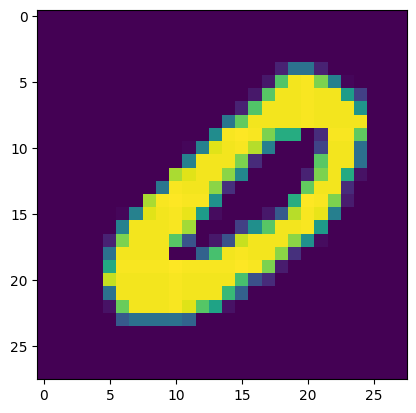

In [29]:
import matplotlib.pyplot as plt
plt.imshow(df.iloc[sample_i,1:].values.reshape(28,28))

In [30]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [43]:
X_train.shape

(15143, 784)

In [44]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

In [45]:
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [46]:
import time
start = time.time()
y_pred = knn.predict(X_Test)
print(time.time() - start)

6.161044359207153


In [47]:
from sklearn.metrics import accuracy_score
accuracy_score(y_pred,y_test)

0.9548335974643423

## Applying PCA to get similar accuracy but in lower Dimension

Step 1: Centering the Data

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [49]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Step 2: import and applying PCA

In [50]:
from sklearn.decomposition import PCA

pca = PCA(n_components=200)

In [51]:
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [52]:
X_train_trf.shape

(15143, 200)

In [53]:
knn = KNeighborsClassifier()

In [54]:
knn.fit(X_train_trf,y_train)

KNeighborsClassifier()

In [55]:
y_pred_trf = knn.predict(X_test_trf)

In [57]:
accuracy_score(y_test,y_pred_trf)

0.9350237717908082

In [78]:
# for i in range(1,785):
#     pca = PCA(n_components=i)
#     X_train_trf = pca.fit_transform(X_train)
#     X_test_trf = pca.transform(X_test)

#     knn = KNeighborsClassifier()

#     knn.fit(X_train_trf,y_train)

#     y_pred = knn.predict(X_test_trf)

#     print(accuracy_score(y_test,y_pred))

#OR:

for i in range(1,785):
    pca = PCA(n_components = i)
    X_train_trf = pca.fit_transform(X_train)
    X_test_trf = pca.transform(X_test)

    knn = KNeighborsClassifier()

    knn.fit(X_train_trf, y_train)

    y_pred_trf = knn.predict(X_test_trf)

    accuracy = accuracy_score(y_test,y_pred_trf)

    print(accuracy)

    var = np.sum(pca.explained_variance_ratio_)

    print("Total variance",var)

    if var > 0.91:
        store_var = var

        print("pc_component: ",i)
        print("accuracy: ", accuracy)

        print("Variance: ", var)
        break

0.24881141045958796
Total variance 0.05832208999058918
0.3322768092974115
Total variance 0.10067020182389036
0.5121500264131009
Total variance 0.14003455306798224
0.6722134178552562
Total variance 0.17054348308636547
0.7319070258848389
Total variance 0.1968598457542748
0.8264659270998416
Total variance 0.21990061693238885
0.8359746434231379
Total variance 0.23989955232144464
0.8565768621236133
Total variance 0.25834167356580184
0.8758584257791865
Total variance 0.2743888378738914
0.8977812995245642
Total variance 0.2889752433529128
0.898837823560486
Total variance 0.3030337509664091
0.9014791336502905
Total variance 0.3157360266974784
0.913365029054411
Total variance 0.3276371333084183
0.9207606973058637
Total variance 0.33906035427088144
0.9231378763866878
Total variance 0.3500557860926099
0.9252509244585314
Total variance 0.3604892332831604
0.9263074484944532
Total variance 0.3703401021776942
0.9300052826201796
Total variance 0.379968289478
0.93026941362916
Total variance 0.389373276

In PCA we dont check the accuracy of model but the variance explained by the PCs, once we reach the above 90% variance we can stop.

90% variance and not 90% accuracy

---

pc_component:  223

accuracy:  0.9323824617010037

Variance:  0.9104069631982291


## Visualize with PCA

2D-component

In [63]:
pca = PCA(n_components=2)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [64]:
import plotly.express as px
y_train_trf = y_train.astype(str)
fig = px.scatter(x=X_train_trf[:,0],
                 y=X_train_trf[:,1],
                 color=y_train_trf,
                 color_discrete_sequence=px.colors.qualitative.G10
                )
fig.show()

3D-Components

In [65]:
pca = PCA(n_components=3)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [66]:
import plotly.express as px
y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=X_train_trf[:,0], y=X_train_trf[:,1], z=X_train_trf[:,2],
              color=y_train_trf)
fig.update_layout(
    margin=dict(l=20, r=20, t=20, b=20),
    paper_bgcolor="LightSteelBlue",
)
fig.show()

In [67]:
pca.explained_variance_
# Eigen values

array([40.01159598, 29.05272328, 27.00572833])

In [68]:
pca.components_.shape
# Eigen vectors

(3, 784)

In [69]:
pca.explained_variance_ratio_

array([0.05832209, 0.04234811, 0.03936435])

Lets see cumualative variance by eigen values

In [70]:
pca = PCA(n_components=None)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [71]:
pca.explained_variance_.shape

(784,)

In [72]:
pca.components_.shape

(784, 784)

In [73]:
np.cumsum(pca.explained_variance_ratio_)

array([0.05832209, 0.1006702 , 0.14003455, 0.17054348, 0.19685985,
       0.21990062, 0.23989955, 0.25834167, 0.27438884, 0.28897524,
       0.30303375, 0.31573603, 0.32763713, 0.33906035, 0.35005579,
       0.36048923, 0.3703401 , 0.37996829, 0.38937328, 0.39845175,
       0.40714804, 0.41547615, 0.42348706, 0.43127994, 0.4389323 ,
       0.44618549, 0.45339512, 0.46035105, 0.46705845, 0.47352968,
       0.47991019, 0.48611108, 0.49226399, 0.49825369, 0.50408448,
       0.50988032, 0.51561095, 0.52121226, 0.52667549, 0.53205389,
       0.5373764 , 0.54255858, 0.54760955, 0.55262766, 0.55758298,
       0.56228244, 0.56694615, 0.5715444 , 0.57607373, 0.58051702,
       0.5849052 , 0.58925099, 0.59356905, 0.5978155 , 0.60198875,
       0.60606182, 0.61005069, 0.6140157 , 0.61791971, 0.62173207,
       0.62547412, 0.62915463, 0.63278463, 0.63639654, 0.6399496 ,
       0.64338261, 0.6468048 , 0.6502118 , 0.65355313, 0.65686513,
       0.66014846, 0.66338224, 0.66658026, 0.66976196, 0.67287

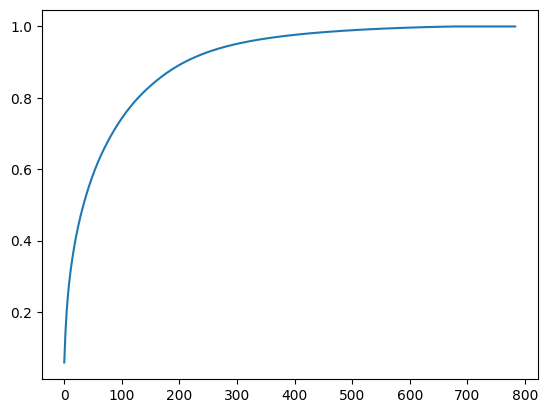

In [74]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))

In [76]:
np.sum(pca.explained_variance_ratio_)

np.float64(1.0000000000000002)